# 1. Demand and spatial analysis — Phase 2
**Member 3: Demand Forecasting + Spatial / Origin-Destination Analytics**

Purpose: validate pickup timestamps and build reproducible, memory-safe demand and OD aggregates from Member 1's official processed data. This phase stops at intermediate tables; forecasting and operational recommendations belong to later phases.

Demand means **one pickup per retained trip row**. The source is the official processed dataset, not a count of all raw records or all actual travel demand. No new cleaning or geography lookup is applied.

## 2. Imports and configuration
Run with Python, DuckDB and PyArrow installed. From the repository root, an isolated environment can be launched with:
```text
python -m uv run --no-project --with duckdb==1.5.5 --with pyarrow==25.0.1 --with jupyter jupyter notebook notebooks/03_demand_and_spatial_analysis.ipynb
```
All project paths are relative. The setup supports a kernel started from the repository root or `notebooks/`. The Member 3 helper contains the SQL transformations. DuckDB scans only the required columns, with a 1 GB engine memory limit, two threads and disk spill under the ignored processed-data directory. This engine limit is not a cap on total Python process memory. No source-sized pandas objects are constructed.

In [1]:
from pathlib import Path
import os
import sys
import importlib
import json
import duckdb
import pyarrow

if not Path("data/processed/clean_trips.parquet").is_file():
    if Path("../data/processed/clean_trips.parquet").is_file():
        os.chdir("..")
    else:
        raise FileNotFoundError("Run from the repository root or notebooks directory")
if "." not in sys.path:
    sys.path.insert(0, ".")
from src import member3_phase2 as phase2
importlib.reload(phase2)
if "con" in globals():
    con.close()
con = phase2.connect()
protected = [Path("data/processed/clean_trips.parquet"), *Path("data/splits").glob("*.parquet"),
             Path("notebooks/01_data_audit_and_cleaning.ipynb"), Path("data/feature_contract.md"),
             Path("docs/MEMBER1_HANDOVER.md"), Path("reports/data_cleaning_decisions.md")]
source_stats = {p: (p.stat().st_size, p.stat().st_mtime_ns) for p in protected}
print(f"DuckDB {duckdb.__version__}; PyArrow {pyarrow.__version__}")

DuckDB 1.5.5; PyArrow 25.0.1


## 3. Member 1 handover verification summary
Phase 1 confirmed **45,533,334 rows, 45 columns and 247 row groups**. Exact readable labels are `pickup_zone_name`, `dropoff_zone_name`, `pickup_borough_name` and `dropoff_borough_name`. `pickup_timestamp` is stored as `large_string`.

References: `data/feature_contract.md`, `docs/MEMBER1_HANDOVER.md`, `reports/data_cleaning_decisions.md`. The cleaning report describes the earlier Step 6 proposal; the handover records completion through Step 9. This notebook uses the handed-over dataset as instructed and retains its selection limitations.

The official chronological boundaries are train before 2025-12-11, validation from 2025-12-11 to before 2026-02-05, and test from 2026-02-05. This descriptive phase does not read or change those splits.

In [2]:
phase2.verify()

Handover verified: 45,533,334 rows, 45 columns, 247 row groups.


## 4. Timestamp parsing validation
An initial eight-row sample showed `YYYY-MM-DD HH:MM:SS`. Parse with `try_strptime(..., '%Y-%m-%d %H:%M:%S')` into a separate `pickup_ts` SQL view column; the original string is preserved. Count nulls and non-null parse failures separately across **every row**, report their combined percentage and timestamp bounds, and stop on any failure without dropping records.

The source sample is not physically sorted. Valid parsed timestamps permit chronological ordering; hourly exports explicitly sort by parsed hour. Timestamps remain timezone-naive as supplied: no timezone or daylight-saving correction is inferred.

In [3]:
timestamps = phase2.validate_timestamps(con)

Timestamp sample: ['2025-04-01 00:47:06', '2025-04-01 00:27:35', '2025-04-01 00:24:07', '2025-04-01 00:56:30', '2025-04-01 00:00:17', '2025-04-01 00:54:37', '2025-04-01 00:11:13', '2025-04-01 00:33:16']


{
  "total_rows": 45533334,
  "null_timestamps": 0,
  "unparseable_timestamps": 0,
  "invalid_timestamps": 0,
  "min_pickup_timestamp": "2025-04-01 00:00:00",
  "max_pickup_timestamp": "2026-03-31 23:59:59",
  "invalid_timestamp_percent": 0.0
}
All pickup timestamps parse; chronological ordering is possible with ORDER BY pickup_ts. Physical source order is not assumed.


## 5. Data coverage summary
Unique counts exclude SQL nulls; null counts are reported separately. Readable labels, including existing special labels, are used exactly as supplied. All null geography groups remain in full aggregates; no names are invented or filled.

In [4]:
summary = phase2.coverage(con, timestamps)

{
  "total_rows": 45533334,
  "null_timestamps": 0,
  "unparseable_timestamps": 0,
  "invalid_timestamps": 0,
  "min_pickup_timestamp": "2025-04-01 00:00:00",
  "max_pickup_timestamp": "2026-03-31 23:59:59",
  "invalid_timestamp_percent": 0.0,
  "unique_pickup_zones": 260,
  "unique_pickup_boroughs": 7,
  "null_pickup_zone_name": 68352,
  "null_pickup_borough_name": 20707,
  "null_dropoff_zone_name": 82030,
  "null_dropoff_borough_name": 211432
}


## 6. Memory-safe hourly demand aggregation
Group by parsed pickup hour, pickup zone and pickup borough and count retained trips. The derived `pickup_hour` is an hourly timestamp in this analysis table; it does not overwrite Member 1's integer hour-of-day field. Preserve observed groups, including null labels. Require the sum of hourly counts to equal the source row count.

In [5]:
phase2.hourly(con)

Hourly aggregate: 1,442,391 rows; 45,533,334 pickups reconciled.


## 7. Top-zone selection and compact demand EDA
Rank readable pickup zone names by total retained pickups across the full observed period, with name as a deterministic tie-break. Select the top 10 non-null names. Verify that each selected zone maps to one supplied borough before assigning its label.

Only these 10 zones receive the complete hourly grid from the minimum to maximum observed hour, inclusive. Fill zero **only when no aggregate row exists**, and retain a `filled_zero` indicator. Assumption: the source covers this period, so an absent zone-hour means zero recorded retained pickups. This does not establish zero actual demand or rule out missing source coverage. Timezone-naive clock changes are not corrected; a nonexistent local clock hour may consequently be represented by zero. First/last hours can be partial at the observed boundaries. Report global absent hours so the assumption is visible.

The ranking is descriptive and uses the full period as requested. Later honest forecasting evaluation must select zones using training data or explicitly treat these zones as a fixed retrospective cohort; this full-period ranking must not be presented as training-only selection.

Prepare total pickups by hour of day, ISO weekday (Monday=1), zone and borough. These are volume totals, not exposure-normalized hourly or daily averages.

In [6]:
phase2.top_zones(con)

(1, 'Upper East Side South', 2014915)
(2, 'JFK Airport', 1923134)
(3, 'Midtown Center', 1922045)
(4, 'Upper East Side North', 1770798)
(5, 'Penn Station/Madison Sq West', 1433926)
(6, 'Midtown East', 1408405)
(7, 'Times Sq/Theatre District', 1364421)
(8, 'Lincoln Square East', 1295316)
(9, 'LaGuardia Airport', 1213660)
(10, 'Murray Hill', 1202194)
Complete top-zone series: 87,600 rows; 718 absent zone-hours filled with zero.
Global hours with no records: 1


## 8. Memory-safe origin-destination aggregation
Scan the official Parquet directly for full zone-to-zone, borough-to-borough and time-bucketed OD counts. Null endpoints remain separate SQL groups, and each full table must reconcile to the source count.

Time buckets are based on pickup clock time with half-open boundaries:
- Morning peak: [06:00, 10:00)
- Midday: [10:00, 16:00)
- Evening peak: [16:00, 20:00)
- Late night: [20:00, 24:00) and [00:00, 06:00)

Buckets are mutually exclusive and cover every parsed pickup. Both zone and borough OD tables are produced by bucket.

In [7]:
phase2.od(con)

od_zone: 55,182 aggregate rows; 45,533,334 trips reconciled.
od_borough: 64 aggregate rows; 45,533,334 trips reconciled.
od_zone_time: 183,686 aggregate rows; 45,533,334 trips reconciled.
od_borough_time: 251 aggregate rows; 45,533,334 trips reconciled.


## 9. Save intermediate aggregated tables
Full hourly and OD Parquet tables use Zstandard compression under `data/processed/member3_*.parquet`. Existing `.gitignore` rules exclude them; do not force-add these outputs. Re-running replaces only these Member 3 outputs.

Small CSV reports contain the top-10 ranking, all zone/borough demand totals, hour/weekday totals, top 100 overall zone OD pairs, all borough OD pairs, all bucketed borough pairs, and top 25 zone OD pairs per bucket. **Zone OD CSVs are explicitly truncated summaries**; the corresponding Parquet files contain every pair. Empty CSV fields represent SQL nulls; Parquet preserves null types. Full-aggregate reconciliation does not apply to truncated reports.

The JSON summary records coverage, zero-fill count and each table's row count and exact byte size.

In [8]:
outputs = phase2.save(con, summary)

Global hours without source records: ['2026-03-08 02:00:00']
data/processed/member3_hourly_demand.parquet: 1,442,391 rows; 2,404,708 bytes
data/processed/member3_top_zone_hourly.parquet: 87,600 rows; 182,251 bytes
data/processed/member3_od_zone_pairs.parquet: 55,182 rows; 140,882 bytes
data/processed/member3_od_borough_pairs.parquet: 64 rows; 1,186 bytes
data/processed/member3_od_zone_time.parquet: 183,686 rows; 393,098 bytes
data/processed/member3_od_borough_time.parquet: 251 rows; 1,904 bytes
reports/member3_top_zones.csv: 10 rows; 336 bytes
reports/member3_demand_by_hour.csv: 24 rows; 298 bytes
reports/member3_demand_by_weekday.csv: 7 rows; 168 bytes
reports/member3_pickup_zone_totals.csv: 261 rows; 6,124 bytes
reports/member3_pickup_borough_totals.csv: 8 rows; 155 bytes
reports/member3_od_zone_pairs.csv: 100 rows; 4,435 bytes
reports/member3_od_borough_pairs.csv: 64 rows; 1,378 bytes
reports/member3_od_borough_time.csv: 251 rows; 7,841 bytes
reports/member3_od_zone_time_top.csv: 10

## 10. Phase 2 summary
The cell below confirms completion only after timestamp, count and complete-index checks pass. Member 1 file sizes and modification times are compared with the setup snapshot. This is an unchanged-file check, not a cryptographic content audit.

Review the recorded coverage and output inventory above before later modelling. Forecasting, final charts and final operational recommendations have not started.

In [9]:
assert all((p.stat().st_size, p.stat().st_mtime_ns) == before for p, before in source_stats.items()), "STOP: Member 1 file metadata changed"
saved_grid = con.execute("SELECT pickup_hour, pickup_zone_name, pickup_count, filled_zero FROM read_parquet('data/processed/member3_top_zone_hourly.parquet')").fetchall()
assert [(r[0], r[1]) for r in saved_grid] == sorted((r[0], r[1]) for r in saved_grid), "STOP: saved grid is not chronological"
assert len({(r[0], r[1]) for r in saved_grid}) == len(saved_grid), "STOP: duplicate zone-hours"
assert all(r[2] >= 0 and (not r[3] or r[2] == 0) for r in saved_grid), "STOP: invalid saved counts"
del saved_grid  # This check reads only the compact 87,600-row grid.
print(f"Phase 2 complete: {summary['total_rows']:,} retained pickups; {summary['invalid_timestamps']} invalid timestamps.")
print(f"Coverage: {summary['min_pickup_timestamp']} through {summary['max_pickup_timestamp']}.")
print(f"Saved {len(outputs)} aggregate tables; Member 1 file sizes and modification times unchanged.")
con.close()

Phase 2 complete: 45,533,334 retained pickups; 0 invalid timestamps.
Coverage: 2025-04-01 00:00:00 through 2026-03-31 23:59:59.
Saved 15 aggregate tables; Member 1 file sizes and modification times unchanged.


# 11. Phase 3 — Demand forecasting
Use only the committed 87,600-row top-zone hourly table. Demand is retained pickup count, with the existing 718 zero-filled zone-hours unchanged. The ten zones were selected retrospectively from the full period in Phase 2; evaluation is **conditional on this fixed cohort**, not an unbiased evaluation of zone selection.

Phase 3 can run independently from this section without rerunning Phase 2 aggregation. Python dependencies: pandas, NumPy, scikit-learn, PyArrow and matplotlib. The execution below records installed versions. No full trip dataset is loaded.
```text
python -m uv run --no-project --with pandas==3.0.5 --with numpy==2.5.3 --with scikit-learn==1.9.0 --with matplotlib==3.11.1 --with pyarrow==25.0.1 --with jupyter jupyter notebook notebooks/03_demand_and_spatial_analysis.ipynb
```

In [1]:
from pathlib import Path
import os
import sys
import importlib
import pandas as pd
import numpy as np
import sklearn
import matplotlib
from IPython.display import display, Image
if not Path('data/processed/member3_top_zone_hourly.parquet').is_file():
    if Path('../data/processed/member3_top_zone_hourly.parquet').is_file():
        os.chdir('..')
    else:
        raise FileNotFoundError('Phase 2 aggregate not found')
if '.' not in sys.path:
    sys.path.insert(0, '.')
from src import member3_forecasting as forecasting
importlib.reload(forecasting)
protected_paths = [Path('data/processed/clean_trips.parquet'), *Path('data/splits').glob('*.parquet'),
    *Path('data/processed').glob('member3_*.parquet'), *Path('reports').glob('member3_*.csv'),
    Path('data/feature_contract.md'), Path('docs/MEMBER1_HANDOVER.md'),
    Path('reports/data_cleaning_decisions.md'), Path('notebooks/01_data_audit_and_cleaning.ipynb')]
# Phase 3 outputs may already exist on rerun; only preserve Member 1 and Phase 2 artifacts here.
protected_paths = [p for p in protected_paths if 'forecast' not in p.name]
before_stats = {p: (p.stat().st_size, p.stat().st_mtime_ns) for p in protected_paths}
print('Versions:', {'pandas': pd.__version__, 'numpy': np.__version__, 'sklearn': sklearn.__version__, 'matplotlib': matplotlib.__version__})
wide = forecasting.load_data()

Versions: {'pandas': '3.0.5', 'numpy': '2.5.3', 'sklearn': '1.9.0', 'matplotlib': '3.11.1'}


Validated compact input: 87,600 rows, 10 zones, 8,760 consecutive hours.


## 12. Seasonal baseline and lag-feature model
**Baseline:** mean historical pickups for the same zone, weekday (Monday=0) and clock hour. Fit on observations strictly before the relevant fitting cutoff; all 168 weekday/hour groups must exist. Means remain fixed throughout each evaluation split.

**Improved candidate:** one HistGradientBoostingRegressor shared by all ten zones. Features are lag 1/24/48/168, trailing 3/24-hour means shifted by one hour, hour, weekday, weekend indicator and an explicitly categorical zone code. The first 168 hours of each zone are unavailable for model fitting; this is lag warm-up, not source cleaning.

Parameters fixed before evaluation: 120 iterations, learning rate 0.08, 15 leaves, minimum 30 samples per leaf, L2=1, seed 2026. Early stopping is disabled to avoid an automatic random validation split. Two computation threads limit overhead. Negative forecasts are clipped to zero; fractional expected counts are retained.

**Multi-step rule:** for each origin, the recursive function receives only observations before that origin. It predicts all zones one hour at a time and appends its own predictions. Any lag or rolling window crossing the origin uses those predictions, never future observed targets. Actual demand revealed before later origins may be used as fresh lag history. Model parameters do not update inside the validation/test split.

## 13. Chronological validation and test evaluation
- Train: 2025-04-01 through 2025-12-10; evaluate validation from 2025-12-11 through 2026-02-04.
- Refit the same configuration on train + validation; evaluate test from 2026-02-05 through 2026-03-31.
- Daily midnight origins are eligible only when their entire 72-hour path lies within the split: 54 validation origins and 53 test origins. Use these same origins for all horizons.
- A horizon score pools the **first H hourly predictions**, not only the Hth lead, equally over every origin and zone. The 48/72-hour windows overlap; repeated target hours represent different forecast origins. These scores are not independent-sample uncertainty estimates. Shorter horizons consequently end earlier than the full split boundary.
- Report MAE and RMSE in pickups per zone-hour. Winner is determined by MAE. The candidate configuration is not tuned on test results.

Primary scores retain the documented zero at 2026-03-08 02:00, consistent with Phase 2. A separate sensitivity CSV excludes only target predictions for that globally absent hour; it does not alter source data, training or lag history. No timezone correction is inferred.

In [2]:
feature_data, backtests, metrics, evaluation_seconds = forecasting.evaluate(wide)
display(metrics)

Fit through 2025-12-10 23:00:00: 59,280 lag-feature rows.


validation: 54 daily origins, 2025-12-11 00:00:00 through 2026-02-02 00:00:00.
     split  horizon_hours  n_predictions  n_origins  baseline_mae  baseline_rmse  improved_mae  improved_rmse   winner
validation             24          12960         54  46.578288242   72.651023923  37.619227263   59.089615377 Improved
validation             48          25920         54  46.332168395   72.258484769  41.017246156   64.229846803 Improved
validation             72          38880         54  46.081913820   71.926199672  42.966829933   67.256696682 Improved


Fit through 2026-02-04 23:00:00: 72,720 lag-feature rows.


test: 53 daily origins, 2026-02-05 00:00:00 through 2026-03-29 00:00:00.
split  horizon_hours  n_predictions  n_origins  baseline_mae  baseline_rmse  improved_mae  improved_rmse   winner
 test             24          12720         53  33.603788911   53.826564740  32.302992781   52.090000550 Improved
 test             48          25440         53  33.574418557   53.772857929  34.268282886   55.024541569 Baseline
 test             72          38160         53  33.571390821   53.751538591  35.188656381   56.369612289 Baseline


,split,horizon_hours,n_predictions,n_origins,baseline_mae,baseline_rmse,improved_mae,improved_rmse,winner
0,validation,24,12960,54,46.578288,72.651024,37.619227,59.089615,Improved
1,validation,48,25920,54,46.332168,72.258485,41.017246,64.229847,Improved
2,validation,72,38880,54,46.081914,71.926200,42.966830,67.256697,Improved
3,test,24,12720,53,33.603789,53.826565,32.302993,52.090001,Improved
4,test,48,25440,53,33.574419,53.772858,34.268283,55.024542,Baseline
5,test,72,38160,53,33.571391,53.751539,35.188656,56.369612,Baseline


## 14. Save forecasts and visualize held-out demand
The diagnostic chart shows the **last eligible test origin**, chosen by date, summing the ten zones. It is an illustrative path; reported scores remain per-zone and use all origins.

After evaluation, refit both methods on all observed data and forecast 2026-04-01 00:00 through 2026-04-03 23:00. `reports/forecast_24h.csv`, `forecast_48h.csv` and `forecast_72h.csv` contain both forecasts, origin, target hour, zone and lead. These future predictions have no observed targets and are not the source of reported test scores. The shorter files are prefixes of the same 72-hour forecast.

Full validation/test predictions are saved to ignored `data/processed/member3_forecast_backtest.parquet` for audit. Metrics, sensitivity results and run summary are small reports; no model binary is saved.

Fit through 2026-03-31 23:00:00: 85,920 lag-feature rows.
[
  {
    "path": "reports/forecast_24h.csv",
    "rows": 240,
    "bytes": 21627
  },
  {
    "path": "reports/forecast_48h.csv",
    "rows": 480,
    "bytes": 43286
  },
  {
    "path": "reports/forecast_72h.csv",
    "rows": 720,
    "bytes": 64921
  }
]
Evaluation runtime: 15.7 seconds. Future forecasts start 2026-04-01 00:00:00.


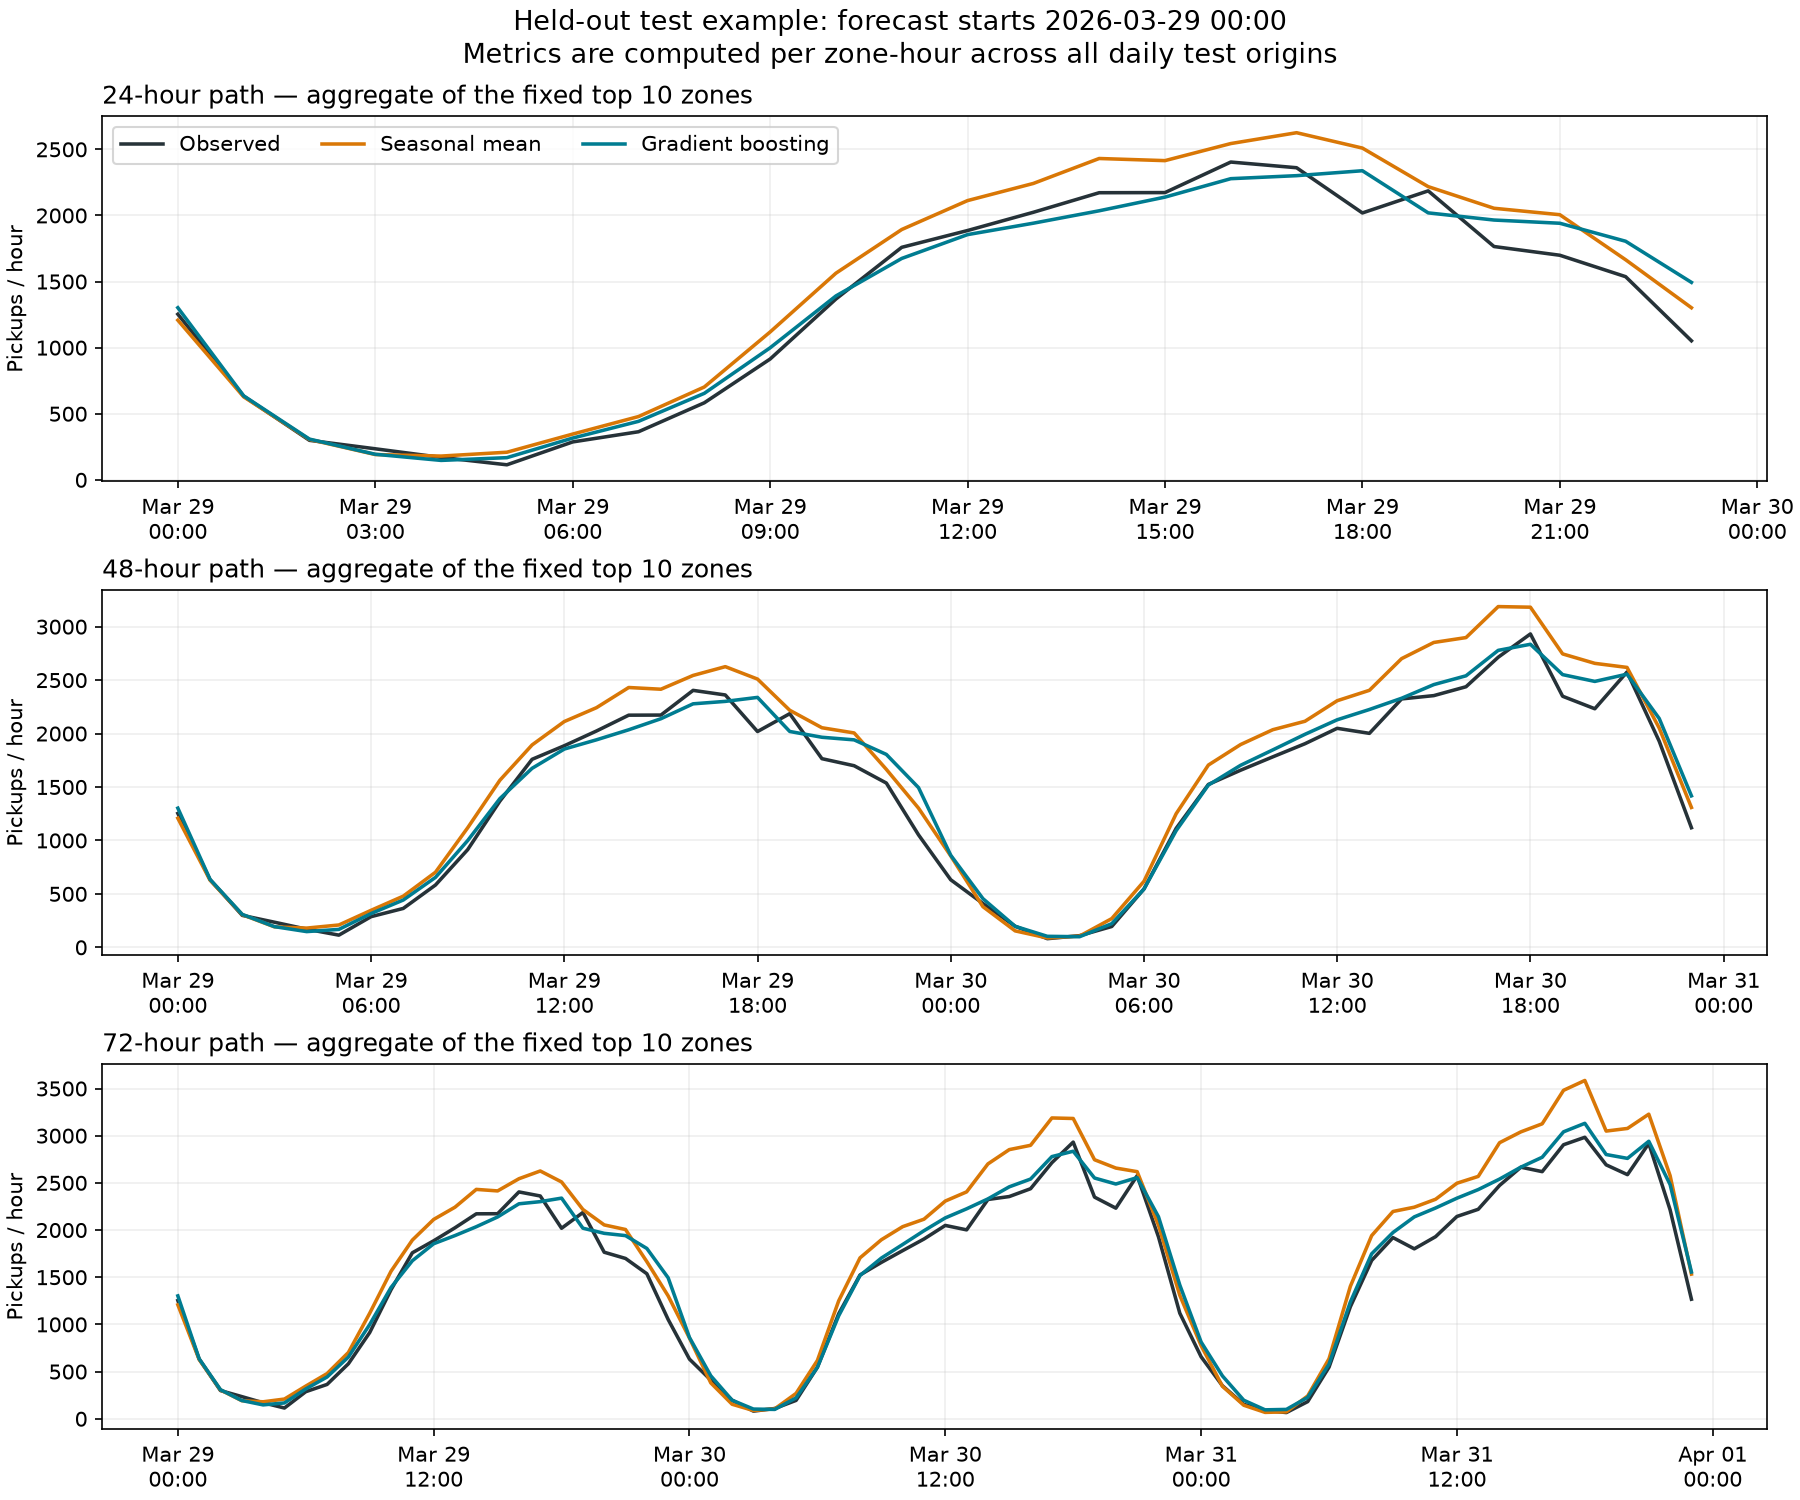

In [3]:
forecast_summary = forecasting.save_outputs(wide, feature_data, backtests, metrics, evaluation_seconds)
display(Image(filename='reports/figures/demand_forecast.png'))

## 15. Comparison and short interpretation
The printed table below uses held-out test data. Improvements describe this fixed retrospective cohort and the selected daily-origin protocol. No operational recommendations are made in this phase.

In [4]:
test_metrics = metrics.loc[metrics.split.eq('test')].copy()
comparison = test_metrics[['horizon_hours', 'baseline_mae', 'improved_mae', 'winner']]
print(comparison.to_string(index=False, float_format=lambda x: f'{x:.9f}'))
for row in test_metrics.itertuples():
    change = 100 * (row.baseline_mae - row.improved_mae) / row.baseline_mae
    print(f'{row.horizon_hours}h: {row.winner} wins by MAE; candidate MAE reduction {change:.2f}%. '
          f'Baseline RMSE {row.baseline_rmse:.9f}; candidate RMSE {row.improved_rmse:.9f}.')
assert all((p.stat().st_size, p.stat().st_mtime_ns) == old for p, old in before_stats.items()), 'STOP: protected input file changed'
print('Phase 3 complete. Member 1 and Phase 2 input sizes and modification times unchanged.')

 horizon_hours  baseline_mae  improved_mae   winner
            24  33.603788911  32.302992781 Improved
            48  33.574418557  34.268282886 Baseline
            72  33.571390821  35.188656381 Baseline
24h: Improved wins by MAE; candidate MAE reduction 3.87%. Baseline RMSE 53.826564740; candidate RMSE 52.090000550.
48h: Baseline wins by MAE; candidate MAE reduction -2.07%. Baseline RMSE 53.772857929; candidate RMSE 55.024541569.
72h: Baseline wins by MAE; candidate MAE reduction -4.82%. Baseline RMSE 53.751538591; candidate RMSE 56.369612289.
Phase 3 complete. Member 1 and Phase 2 input sizes and modification times unchanged.
